In [1]:
# Imports
#This code requires the G2S server to be running

import numpy
from PIL import Image
import requests
from io import BytesIO
from g2s import g2s
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import math
import torch
import torch.nn as nn

import argparse
import torch
import datetime
import json
import yaml
import os

import sys

sys.path.append(".")
sys.path.append("./models")

from models.unet_main_model import Unet_WaterQual
from utils import *

import matplotlib.pyplot as plt

In [18]:
!nvidia-smi

Fri May 29 10:34:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      On  |   00000000:C4:00.0 Off |                    0 |
| N/A   47C    P0             35W /   72W |     226MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [3]:
#Load data
#rq: temporal resolution = 4h

from dataset_ope import get_dataloader
gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, _, test_loader, _, _ = get_dataloader(device=gpu, batch_size=8)

parameters_name = np.loadtxt("data/ope_andra/sagd_parameters_50_hte.csv", dtype=str)

Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


In [4]:
main_data = test_loader.dataset.main_data
mask_data = test_loader.dataset.mask_data

main_data[mask_data == 0] = np.nan

timepoints = test_loader.dataset.timepoints
total_length = len(main_data)

start_train = 0
end_train = total_length - test_loader.dataset.seq_length - test_loader.dataset.valid_length - test_loader.dataset.test_length + 1
train_data = main_data[start_train:end_train]

start_valid = total_length - test_loader.dataset.seq_length - test_loader.dataset.valid_length - test_loader.dataset.test_length + test_loader.dataset.pred_length
end_valid = total_length - test_loader.dataset.seq_length - test_loader.dataset.test_length + test_loader.dataset.pred_length
valid_data = main_data[start_valid:end_valid]

start_test = total_length - test_loader.dataset.seq_length - test_loader.dataset.test_length + test_loader.dataset.pred_length
end_test = total_length - test_loader.dataset.seq_length + test_loader.dataset.pred_length
test_data = main_data[start_test:end_test]

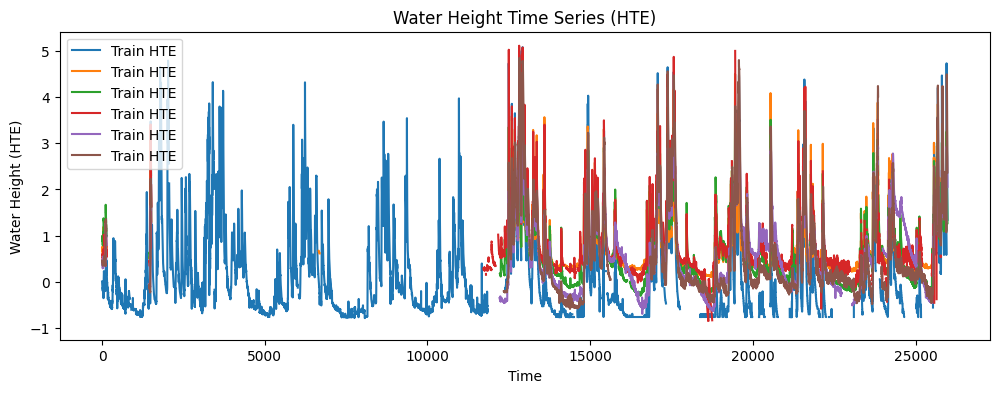

In [5]:
# Plot training hte time series where parameter name contains "hte"
hte_idx = np.where(np.char.find(parameters_name, "hte") != -1)
plt.figure(figsize=(12, 4))
plt.plot(main_data[:, hte_idx][:, 0], label="Train HTE")
plt.title("Water Height Time Series (HTE)")
plt.xlabel("Time")
plt.ylabel("Water Height (HTE)")
plt.legend()
plt.show()

In [6]:
print("train data shape:", train_data.shape)
print("valid data shape:", valid_data.shape)
print("test data shape:", test_data.shape)

train data shape: (25670, 75)
valid data shape: (120, 75)
test data shape: (168, 75)


In [7]:
covariates = np.genfromtxt('./data/ope_andra/safran_covariates.csv', delimiter=',', usemask=True, filling_values=0)
covariates_names = pd.read_csv('./data/ope_andra/safran_parameters_names.csv')

# select some covariates
covariates_step1 = covariates[:, [32, 38, 68]]
# sum columns 32 and 38 into one column
sum_32_38 = covariates_step1[:, 0] + covariates_step1[:, 1]

# stack the summed column with column 68
covariates_step1 = np.column_stack((sum_32_38, covariates_step1[:, 2]))

covariates_step2 = np.expand_dims(covariates[:, 68], axis=1)

In [8]:
print("covariates_step1 data shape:", covariates_step1.shape)
print("covariates_step2 data shape:", covariates_step2.shape)

covariates_step1 data shape: (25981, 2)
covariates_step2 data shape: (25981, 1)


In [9]:
#----Define global parameters (used for step1 and step2)----
bool_include_covariates=True

nb_realiz = 1

nb_neighboors = 12 # 12 time steps = 2 days

In [10]:
#----Set-up the simulation----
# Only Water Height for the first step, and all variables for the second step
inds_WaterHeight = list(range(69,75))              
nb_neighboors_step1 = nb_neighboors # in time   

In [11]:
# Extract data, the mask is implicity taken into account by the librairy
# Di and Ti can be the same, but we'll do a training vs testing split similar to the other models !

nb_stations=len(inds_WaterHeight)
print("number of stations:", nb_stations)

number of stations: 6


In [12]:
if not bool_include_covariates:
    M_WaterHeight = train_data[:, inds_WaterHeight]
    nb_covariates = 0
else:
    M_WaterHeight = np.hstack((
        covariates_step1[start_train:end_train, :],
        train_data[:, inds_WaterHeight]
    ))
    nb_covariates = covariates.shape[-1]

# Create training and destination images, as well as matrix to store simulations (M_Simul_step1)
M_TI_step1=M_WaterHeight #Training Image

# data is already normalized, so no need to standardize it for the MPS

M_DI_step1=M_TI_step1 #Destination image: for gap filling the destination image equals the training image
M_Simul_step1 = np.full(
    (*M_TI_step1.shape, nb_realiz),
    np.nan
)

In [13]:
# Let's see the shapes
print("M_TI_step1 shape:", M_TI_step1.shape)
print("M_DI_step1 shape:", M_DI_step1.shape)
print("M_Simul_step1 shape:", M_Simul_step1.shape)

M_TI_step1 shape: (25670, 8)
M_DI_step1 shape: (25670, 8)
M_Simul_step1 shape: (25670, 8, 1)


In [14]:
V_Data_Type = np.zeros((1, M_TI_step1.shape[1]))
my_realiz = 0

kernel_step1 = np.ones((nb_neighboors_step1, len(V_Data_Type)))

n_covariates = covariates_step1.shape[1]

kernel_step1[:, :n_covariates] *= 1 / n_covariates

In [19]:
# QS call using G2S
V_Data_Type = np.zeros(M_TI_step1.shape[1])
my_realiz = 0

while my_realiz < nb_realiz:

    print(my_realiz)

    if bool_include_covariates == 0:

        simulation, *_ = g2s(
            '-a', 'qs',
            '-ti', M_TI_step1,
            '-di', M_DI_step1,
            '-dt', V_Data_Type,
            '-k', 1.2,
            '-n', nb_neighboors_step1,
            '-j', 0.5,
            '-W_CUDA',0
        )

    else:
        # Build kernel
        kernel_step1 = np.ones((nb_neighboors_step1, len(V_Data_Type)))
        n_covariates = covariates_step1.shape[1]
        kernel_step1[:, :n_covariates] = 1 / n_covariates

        simulation, *_ = g2s(
            '-a', 'qs',
            '-ti', M_TI_step1,
            '-di', M_DI_step1,
            '-dt', V_Data_Type,
            '-k', 1.2,
            '-n', nb_neighboors_step1,
            '-ki', kernel_step1,
            '-j', 0.5,
            '-W_CUDA',0
        )

    # Verify that the simulation is not empty
    if np.sum(simulation) > 0:
        # Store realization. nb: We keep the data normalized
        M_Simul_step1[:, :, my_realiz] = simulation
        my_realiz += 1

0
job Id is: 2077843985
progress 100.000%       
        

In [20]:
M_TI_step1.shape

(25670, 8)

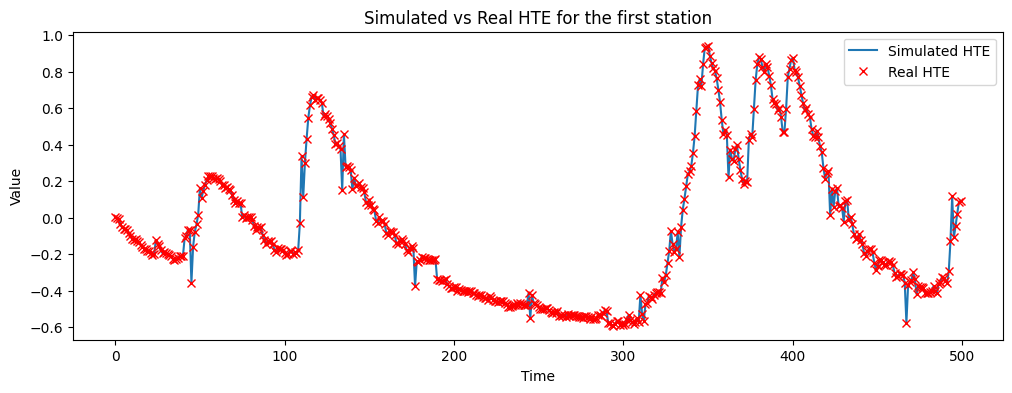

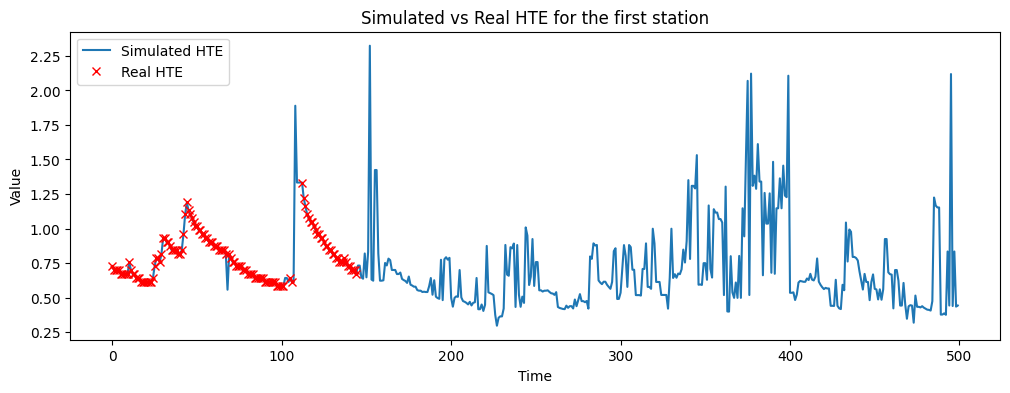

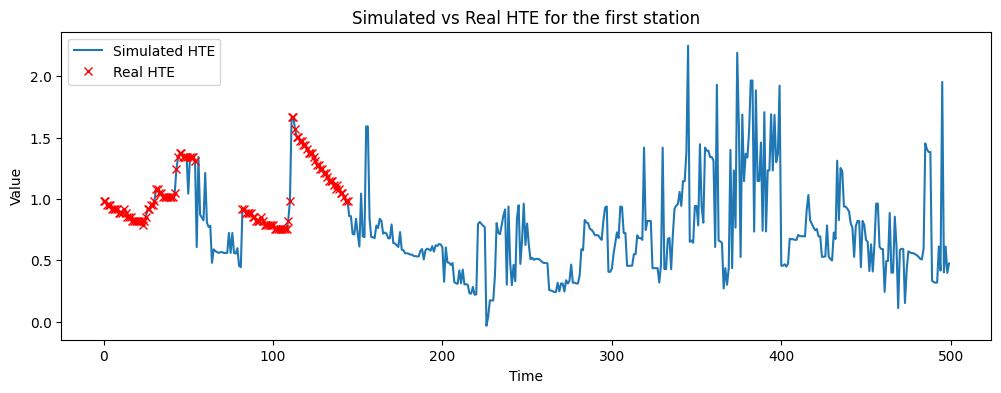

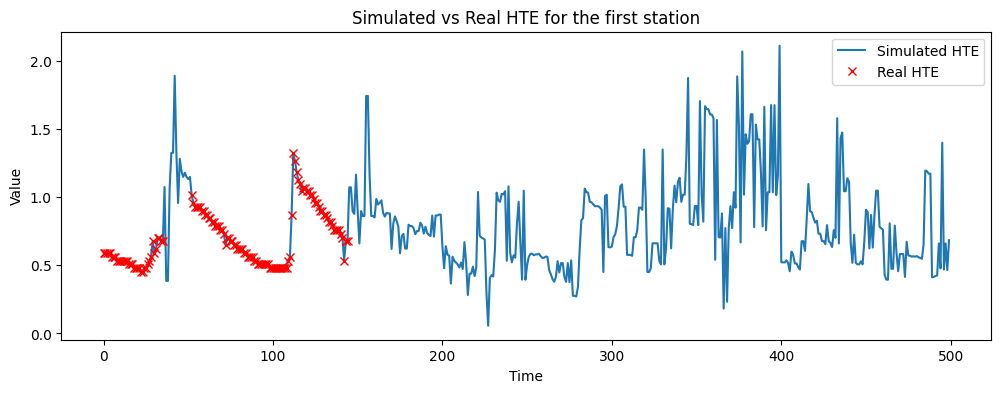

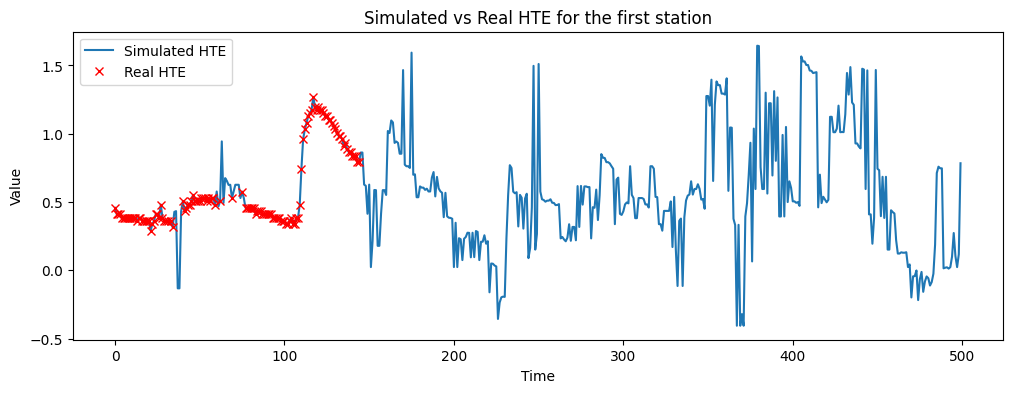

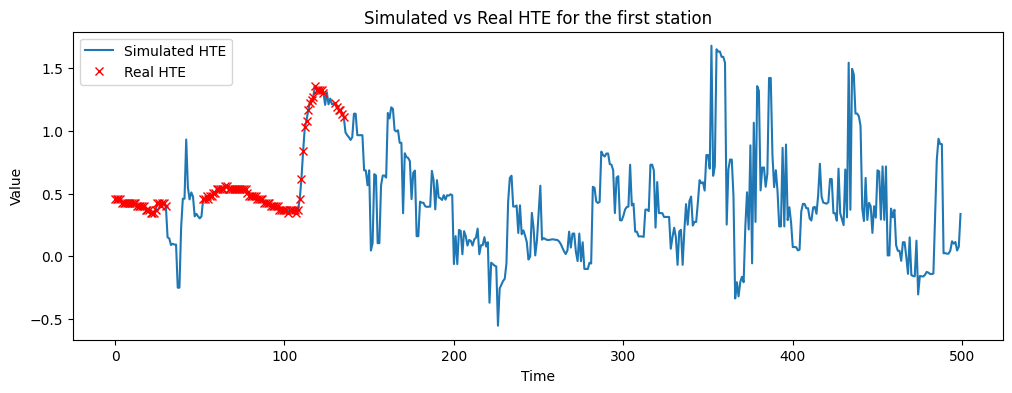

In [21]:
# print simulated hte vs the real hte for all stations
# remove two first columns of M_TI_step1 and M_Simul_step1 (corresponding to the covariates)
M_TI_step1 = M_TI_step1[:, 2:]
M_Simul_step1 = M_Simul_step1[:, 2:, :]

for s in range(M_TI_step1.shape[1]):
    plt.figure(figsize=(12, 4))
    # print the simulation with dots
    plt.plot(M_Simul_step1[:500, s, 0], label="Simulated HTE")
    plt.plot(M_TI_step1[:500, s], label="Real HTE", color = 'r',marker = 'x', linestyle='None')
    plt.title("Simulated vs Real HTE for the first station")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()

In [ ]:
n_rows = len(train_data)
n_total_vars = train_data.shape[1]
M_Simul_step2_total = np.zeros((n_rows, n_total_vars, nb_realiz))  # Initialized with zeros

nb_neighboors_step2 = nb_neighboors
threshold_frequency = 0.6  # Threshold for frequency of NaNs to include a variable in the simulation

V_stationNames = np.array([row.split("_")[0] for row in parameters_name.squeeze()])

for my_station, water_idx in enumerate(inds_WaterHeight):

    station_name = np.array(parameters_name[water_idx].split("_")[0])

    # --- Find all variables belonging to this station ---
    inds_var_ini = np.where(V_stationNames == station_name)[0]

    # --- Compute frequency of NaNs ---
    data_subset = train_data[:, inds_var_ini]
    V_freq_nan = np.sum(np.isnan(data_subset), axis=0) / len(train_data)

    inds_var = inds_var_ini[V_freq_nan < threshold_frequency]

    # Remove water height index
    inds_var = inds_var[inds_var != water_idx]

    # ---- Allocate storage for this station's simulation ----
    n_cols_station = len(inds_var) + 1  # +1 for water height
    if bool_include_covariates:
        n_cols_station += covariates_step2.shape[1]

    M_Simul_step2 = np.zeros((n_rows, n_cols_station, nb_realiz))  # zeros instead of NaNs

    # ==============================
    # Simulation loop
    # ==============================
    my_realiz = 0
    while my_realiz < nb_realiz:

        print(f"Simulating realization {my_realiz} for station {station_name}")

        # --- Build training image ---
        if not bool_include_covariates:
            M_WaterParameters_1station = np.column_stack((
                M_Simul_step1[:, my_station, my_realiz],  # Water height
                train_data[:, inds_var]                   # Other station variables
            ))
        else:
            M_WaterParameters_1station = np.column_stack((
                covariates_step2[start_train:end_train, :],
                M_Simul_step1[:, my_station, my_realiz],
                train_data[:, inds_var]
            ))

        M_TI_step2 = M_WaterParameters_1station
        M_DI_step2 = M_TI_step2.copy()

        # ---- QS ----
        V_Data_Type_step2 = np.zeros(M_TI_step2.shape[1])

        simulation, *_ = g2s(
            '-a', 'qs',
            '-ti', M_TI_step2,
            '-di', M_DI_step2,
            '-dt', V_Data_Type_step2,
            '-k', 1.2,
            '-n', nb_neighboors_step2,
            '-j', 0.5,
            '-W_CUDA',0
        )

        if np.sum(simulation) > 0:
            # Insert simulated values at the correct indices
            # Water height
            M_Simul_step2[:, 0, my_realiz] = simulation[:, 0]
            # Other variables
            M_Simul_step2[:, 1:, my_realiz] = simulation[:, 1:]

            my_realiz += 1

    # Insert this station's simulation back into the global array
    col_indices = np.concatenate(([water_idx], inds_var))
    M_Simul_step2_total[:, col_indices, :] = M_Simul_step2[:, :len(col_indices), :]

print("Simulation completed. Result is a NumPy array with shape:", M_Simul_step2_total.shape)


Simulating realization 0 for station EST3012
job Id is: 4234284286
progress 100.000%       
        Simulating realization 0 for station OPE90011
job Id is: 2993568576
progress 100.000%       
        Simulating realization 0 for station OPE90012
job Id is: 2486923969
progress 19.989%        

In [ ]:
# plot the numpy M_Simul_step2_total of the time series (24907, 75, 1)

for v in range(M_Simul_step2_total.shape[1]):
    plt.figure(figsize=(12, 4))
    plt.plot(M_Simul_step2_total[:, v, 0], label=f"Simulated {parameters_name[v]}")
    plt.title(f"Simulated Time Series for {parameters_name[v]}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()